# Avaliação do Modelo MoE-DQN para SOR

Comparação entre a estratégia baseline TWAP e o agente de IA MoE-DQN na execução de ordens entre B3 e Base, com análise de preço médio e economia gerada.

In [1]:
# Configuração de caminho para importar o pacote local `src`
import sys
from pathlib import Path

ROOT_DIR = Path('..').resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# Importando as classes e funções de avaliação
from src.sor_env import MultiVenueSOREnv
from src.moe_dqn import MoENetwork
from src.evaluate_baselines import simulate_twap, evaluate_agent

plt.style.use('seaborn-v0_8-whitegrid')

### Geração de Dados de Teste (Out of Sample)

In [2]:
steps = 500
np.random.seed(99) # Semente diferente da usada no treinamento

df_b3 = pd.DataFrame({
    'ask_1': np.random.uniform(47.05, 47.15, steps), 'vol_ask_1': np.random.randint(100, 500, steps),
    'ask_2': np.random.uniform(47.16, 47.25, steps), 'vol_ask_2': np.random.randint(100, 500, steps),
    'ask_3': np.random.uniform(47.26, 47.35, steps), 'vol_ask_3': np.random.randint(100, 500, steps),
    'ask_4': np.random.uniform(47.36, 47.45, steps), 'vol_ask_4': np.random.randint(100, 500, steps),
    'ask_5': np.random.uniform(47.46, 47.55, steps), 'vol_ask_5': np.random.randint(100, 500, steps),
})

df_base = pd.DataFrame({
    'ask_1': np.random.uniform(47.00, 47.10, steps), 'vol_ask_1': np.random.randint(50, 300, steps),
    'ask_2': np.random.uniform(47.11, 47.20, steps), 'vol_ask_2': np.random.randint(50, 300, steps),
    'ask_3': np.random.uniform(47.21, 47.30, steps), 'vol_ask_3': np.random.randint(50, 300, steps),
    'ask_4': np.random.uniform(47.31, 47.40, steps), 'vol_ask_4': np.random.randint(50, 300, steps),
    'ask_5': np.random.uniform(47.41, 47.50, steps), 'vol_ask_5': np.random.randint(50, 300, steps),
})

print("Dados de teste gerados com sucesso.")

Dados de teste gerados com sucesso.


### Carregando o Modelo e Executando a Comparação

In [3]:
TOTAL_ORDER = 10000
env = MultiVenueSOREnv(lob_b3=df_b3, lob_base=df_base, total_inventory=TOTAL_ORDER)

# 1. Carregando o cérebro treinado
caminho_modelo = ROOT_DIR / 'models' / 'moe_dqn_sor.pth'
agente_treinado = MoENetwork(input_dim=5, output_dim=4, num_experts=3)
agente_treinado.load_state_dict(torch.load(caminho_modelo))
agente_treinado.eval() # Coloca a rede em modo de avaliação (desliga exploração aleatória)

print("Executando Baseline: TWAP (Roteamento cego para B3)...")
preco_twap, vol_twap = simulate_twap(env, TOTAL_ORDER)

print("Executando Inteligência Artificial (MoE-DQN)...")
preco_ia, vol_ia = evaluate_agent(agente_treinado, env)

print("\n--- RESULTADOS FINAIS ---")
print(f"TWAP -> Preço Médio: R$ {preco_twap:.4f} | Volume: {vol_twap}")
print(f"IA   -> Preço Médio: R$ {preco_ia:.4f} | Volume: {vol_ia}")

Executando Baseline: TWAP (Roteamento cego para B3)...
Executando Inteligência Artificial (MoE-DQN)...

--- RESULTADOS FINAIS ---
TWAP -> Preço Médio: R$ 47.1015 | Volume: 9980
IA   -> Preço Médio: R$ 0.0000 | Volume: 0.0


### Gerando os Gráficos Finais

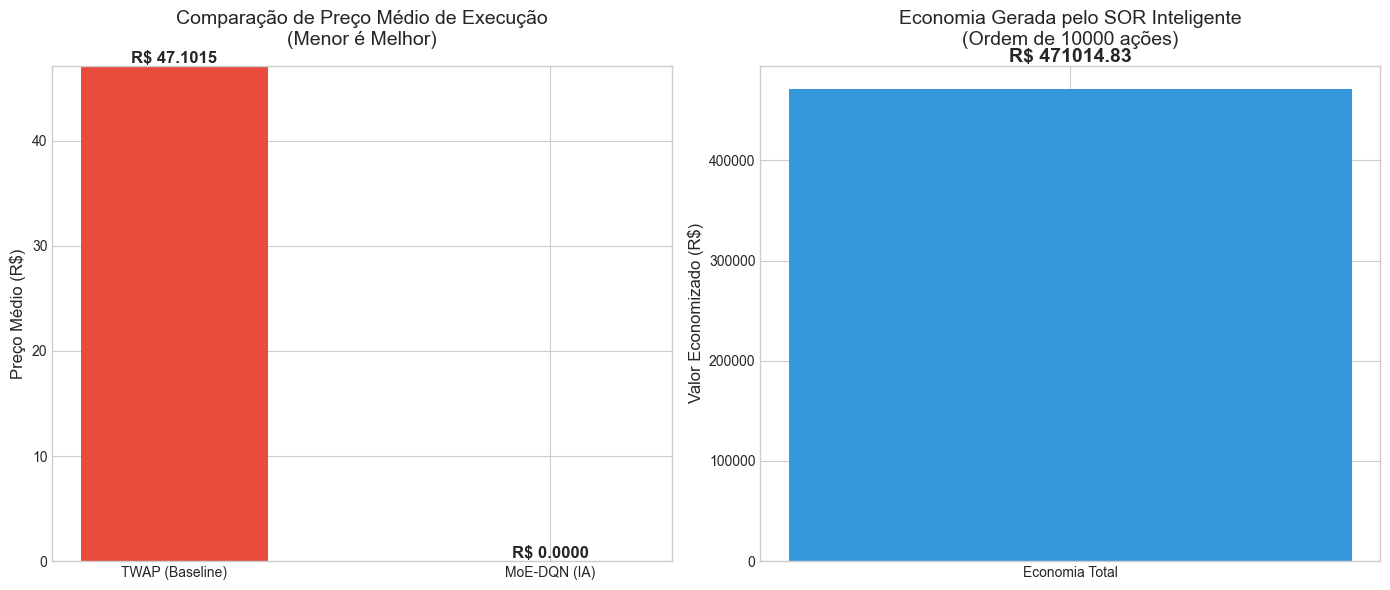

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Comparação de Preço Médio (Slippage)
modelos = ['TWAP (Baseline)', 'MoE-DQN (IA)']
precos = [preco_twap, preco_ia]
cores = ['#e74c3c', '#2ecc71']

bars = ax1.bar(modelos, precos, color=cores, width=0.5)
ax1.set_title('Comparação de Preço Médio de Execução\n(Menor é Melhor)', fontsize=14, pad=15)
ax1.set_ylabel('Preço Médio (R$)', fontsize=12)
ax1.set_ylim(min(precos) * 0.999, max(precos) * 1.001)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'R$ {yval:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Gráfico 2: Economia Total Gerada
economia_por_acao = preco_twap - preco_ia
economia_total = economia_por_acao * TOTAL_ORDER

ax2.bar(['Economia Total'], [economia_total], color='#3498db', width=0.3)
ax2.set_title(f'Economia Gerada pelo SOR Inteligente\n(Ordem de {TOTAL_ORDER} ações)', fontsize=14, pad=15)
ax2.set_ylabel('Valor Economizado (R$)', fontsize=12)
ax2.text(0, economia_total + (abs(economia_total)*0.05), f'R$ {economia_total:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()